# Phase 3: Category Performance Analysis

This notebook evaluates Olist's 73 product categories across three passes:
1. **Static aggregates**: revenue, volume, customer experience, seller diversity, per category
2. **Growth metric**: revenue growth in the recent 6 months vs the prior 6 months
3. **Strategic quadrant**: combining growth and review scores to identify investment priorities

**Source:** `fact_orders` table in MySQL

**Outputs produced:**
- `agg_category_performance` in MySQL: 73 categories with static aggregates + growth metrics
- `category_full.parquet` on disk for downstream use
- Quadrant chart identifying 4 strategic action zones

**Key findings:**
- 35% of marketplace revenue sits in the "Fix Experience" quadrant (growing but rated below average)
- Four high-priority categories: bed_bath_table, watches_gifts, furniture_decor, office_furniture
- office_furniture is the standout problem: 335K BRL revenue with a 3.52 review score
- Housewares is the standout "Invest More" opportunity: 90% growth, 4.11 review, 758K BRL revenue

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import seaborn as sns
%matplotlib inline

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [3]:
import os

USER = 'root'
PASSWORD = os.getenv('MYSQL_PASSWORD', 'YOUR_PASSWORD')
HOST = 'localhost'
PORT = 3306
DB = 'olist'

engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

with engine.connect() as conn:
    print('Connected:', conn.execute(text('SELECT VERSION()')).fetchone()[0])

Connected: 8.0.46


## Section 1: Category-level static aggregates

This section aggregates `fact_orders` to category grain (one row per product category) producing volume, revenue, customer experience, and seller diversity metrics. The aggregation is done in MySQL via a single `GROUP BY` query and pulled into pandas via `pd.read_sql`

Two filters are applied:
- `product_category IS NOT NULL` (excludes a small number of unmapped items)
- `product_category != 'unknown'` (excludes items where category translation failed)

The result is 73 categories ready for analysis. The next section adds growth metrics to this base table. 

In [4]:
category_stats = pd.read_sql("""
    SELECT
        product_category, 
        COUNT(*) AS items_sold,
        COUNT(DISTINCT order_id) AS orders,
        COUNT(DISTINCT customer_unique_id) AS customers,
        COUNT(DISTINCT seller_id) AS distinct_sellers,
        ROUND(SUM(item_total),2) AS total_revenue,
        ROUND(SUM(price), 2) AS product_revenue,
        ROUND(SUM(freight_value), 2) AS freight_revenue,
        ROUND(AVG(item_total), 2) AS avg_item_total,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(freight_value), 2) AS avg_freight,
        ROUND(AVG(review_score), 2) AS avg_review_score, 
        ROUND(SUM(item_total) / COUNT(DISTINCT order_id), 2) AS avg_order_value
    FROM fact_orders
    WHERE product_category IS NOT NULL 
    	AND product_category != 'unknown'
    GROUP BY product_category
    ORDER BY total_revenue DESC
""", engine)

print(f'Categories loaded: {len(category_stats)}')
print(f'\nTop 10 by revenue:')
print(category_stats[['product_category', 'total_revenue', 'orders', 'avg_review_score', 'distinct_sellers']].head(10).to_string(index=False))

print(f'\nBottom 10 by revenue:')
print(category_stats[['product_category', 'total_revenue', 'orders', 'avg_review_score', 'distinct_sellers']].tail(10).to_string(index=False))

Categories loaded: 73

Top 10 by revenue:
     product_category  total_revenue  orders  avg_review_score  distinct_sellers
        health_beauty     1412089.53    8647              4.19               479
        watches_gifts     1264333.12    5495              4.07                95
       bed_bath_table     1225209.26    9272              3.92               189
       sports_leisure     1118256.91    7530              4.17               466
computers_accessories     1032723.77    6530              3.99               279
      furniture_decor      880329.92    6307              3.95               352
           housewares      758392.25    5743              4.11               452
           cool_stuff      691680.89    3559              4.20               259
                 auto      669454.75    3810              4.12               371
         garden_tools      567145.68    3448              4.08               227

Bottom 10 by revenue:
         product_category  total_revenue  or

In [5]:
print(category_stats[['product_category', 'total_revenue', 'orders', 'avg_review_score', 'distinct_sellers']].sort_values('avg_review_score').head(15).to_string(index=False))

                             product_category  total_revenue  orders  avg_review_score  distinct_sellers
                        security_and_services         324.51       2              2.50                 2
                          diapers_and_hygiene        2046.19      25              3.38                 7
portateis_cozinha_e_preparadores_de_alimentos        4228.05      13              3.43                 5
                             office_furniture      335211.36    1254              3.52                30
                               home_comfort_2        1170.58      24              3.63                 4
                                     pc_gamer        1430.10       7              3.63                 2
                        fashion_male_clothing       12514.95     106              3.76                12
                              fixed_telephony       59816.54     212              3.76                48
                               party_supplies        52

# Section 2: Growth metric

The growth metric compares revenue in the recent 6 months (March-August 2018) against the prior 6 months (September 2017 - February 2018). Categories that did not exist in the prior window are flagged as "new_category"; categories that grew >100% are "growing fast"; categories that declined >50% are "declining fast".

Merged with the static aggregates from Section 1, this gives one row per category with both size and trajectory, ready to plot.

In [6]:
category_growth = pd.read_sql("""
    WITH growth_windows AS (
    	SELECT 
    		product_category, 
            SUM(CASE 
    				WHEN order_purchase_timestamp >= '2018-03-01' AND order_purchase_timestamp < '2018-09-01' THEN item_total
                    ELSE 0
    			END) AS revenue_recent_6m, 
    		SUM(CASE 
    				WHEN order_purchase_timestamp >= '2017-09-01' AND order_purchase_timestamp < '2018-03-01' THEN item_total 
                    ELSE 0
    			END) AS revenue_prior_6m,
    		COUNT(DISTINCT CASE
    				WHEN order_purchase_timestamp >= '2018-03-01' AND order_purchase_timestamp < '2018-09-01' THEN order_id 
    			END) AS orders_recent_6m,
    		COUNT(DISTINCT CASE
    				WHEN order_purchase_timestamp >= '2017-09-01' AND order_purchase_timestamp < '2018-03-01' THEN order_id 
    			END) AS orders_prior_6m
    	FROM fact_orders
        WHERE product_category IS NOT NULL AND product_category != 'unknown' AND order_purchase_timestamp >= '2017-09-01' AND order_purchase_timestamp < '2018-09-01'
        GROUP BY product_category
    )
    SELECT 
    	product_category,
        ROUND(revenue_recent_6m, 2) AS revenue_recent_6m,
        ROUND(revenue_prior_6m, 2) AS revenue_prior_6m, 
        orders_recent_6m, 
        orders_prior_6m, 
        CASE 
    		WHEN revenue_prior_6m = 0 AND revenue_recent_6m > 0 THEN NULL
            WHEN revenue_prior_6m = 0 AND revenue_recent_6m = 0 THEN NULL
            ELSE ROUND((revenue_recent_6m - revenue_prior_6m) / revenue_prior_6m * 100, 1)
    	END AS growth_pct, 
        CASE
    		WHEN revenue_prior_6m = 0 AND revenue_recent_6m > 0 THEN 'new_category'
            WHEN revenue_prior_6m = 0 AND revenue_recent_6m = 0 THEN 'dormant'
            WHEN revenue_recent_6m < revenue_prior_6m * 0.5 THEN 'declining_fast'
            WHEN revenue_recent_6m < revenue_prior_6m THEN 'declining'
            WHEN revenue_recent_6m > revenue_prior_6m * 2 THEN 'growing_fast'
            WHEN revenue_recent_6m > revenue_prior_6m THEN 'growing'
            ELSE 'flat'
    	END AS growth_status
    FROM growth_windows
    ORDER BY growth_pct DESC""", engine)

print(f'Categories with growth data: {len(category_growth)}')
print(f'\nGrowth status distribution:')
print(category_growth['growth_status'].value_counts())

print('\nTop 10 fastest-growing categories:')
print(category_growth[category_growth['orders_prior_6m'] >= 50][['product_category','revenue_recent_6m','revenue_prior_6m','growth_pct']].head(10).to_string(index=False))

print('\nTop 10 fastest-declining categories:')
print(category_growth[category_growth['orders_prior_6m'] >= 50][['product_category','revenue_recent_6m','revenue_prior_6m','growth_pct']].sort_values('growth_pct').head(10).to_string(index=False))

Categories with growth data: 73

Growth status distribution:
growth_status
growing           29
declining         20
growing_fast      14
declining_fast     8
new_category       2
Name: count, dtype: int64

Top 10 fastest-growing categories:
               product_category  revenue_recent_6m  revenue_prior_6m  growth_pct
                           food           22034.20           7390.56       198.1
                home_appliances           57247.17          19501.68       193.5
construction_tools_construction          118608.21          40484.80       193.0
              home_appliances_2           74776.09          31170.52       139.9
         books_general_interest           26667.64          13469.00        98.0
                       pet_shop          126841.13          65194.72        94.6
                books_technical           13205.68           6911.48        91.1
                     housewares          393243.63         206590.60        90.3
 industry_commerce_and_busine

In [7]:
category_full = category_stats.merge(category_growth, on='product_category', how='left')

print(f'Merged table: {len(category_full)} categories')
print(f'Categories missing growth data (only in static): {category_full['growth_pct'].isna().sum()}')

category_full.to_parquet('./data/processed/category_full.parquet', index=False)
print('Saved to data/processed/category_full.parquet')


Merged table: 73 categories
Categories missing growth data (only in static): 2
Saved to data/processed/category_full.parquet


In [8]:
category_full.to_sql('agg_category_performance', engine, if_exists='replace', index=False, chunksize=5000)
print('Saved category_full to MySQL as agg_category_performance.')

Saved category_full to MySQL as agg_category_performance.


## Section 3: Strategic quadrant analysis

The quadrant chart plots all categories by growth (x-axis) and review score (y-axis) with bubble size scaled to revenue. Two divider lines (0% growth, mean review score) split categories into four strategic actions:

- **Top-right** (growing + good reviews): INVEST MORE
- **Bottom-right** (growing + below-average reviews): FIX EXPERIENCE
- **Top-left** (declining + good reviews): PROMOTE / CROSS-SELL
- **Bottom-left** (declining + below-average reviews): DELIST / REPOSITION

Categories with too few orders in the prior period (<30) are excluded to avoid noise from small-sample growth volatility. Categories with growth >300% are clipped at 300% for chart readability, their true values still appear in the data table. 

In [9]:
quadrant_data = category_full[(category_full['growth_pct'].notna()) & (category_full['orders_prior_6m'] >= 30)].copy()

# Clip extreme growth values for chart readability
quadrant_data['growth_clipped'] = quadrant_data['growth_pct'].clip(upper=300, lower=-100)
quadrant_data['was_clipped'] = quadrant_data['growth_pct'] > 300

growth_midline = 0
review_midline = quadrant_data['avg_review_score'].mean()

print(f'Categories in chart: {len(quadrant_data)}')
print(f'Review-score midline: {review_midline:.2f}')
print(f'Growth midline: {growth_midline}%')

Categories in chart: 52
Review-score midline: 4.11
Growth midline: 0%


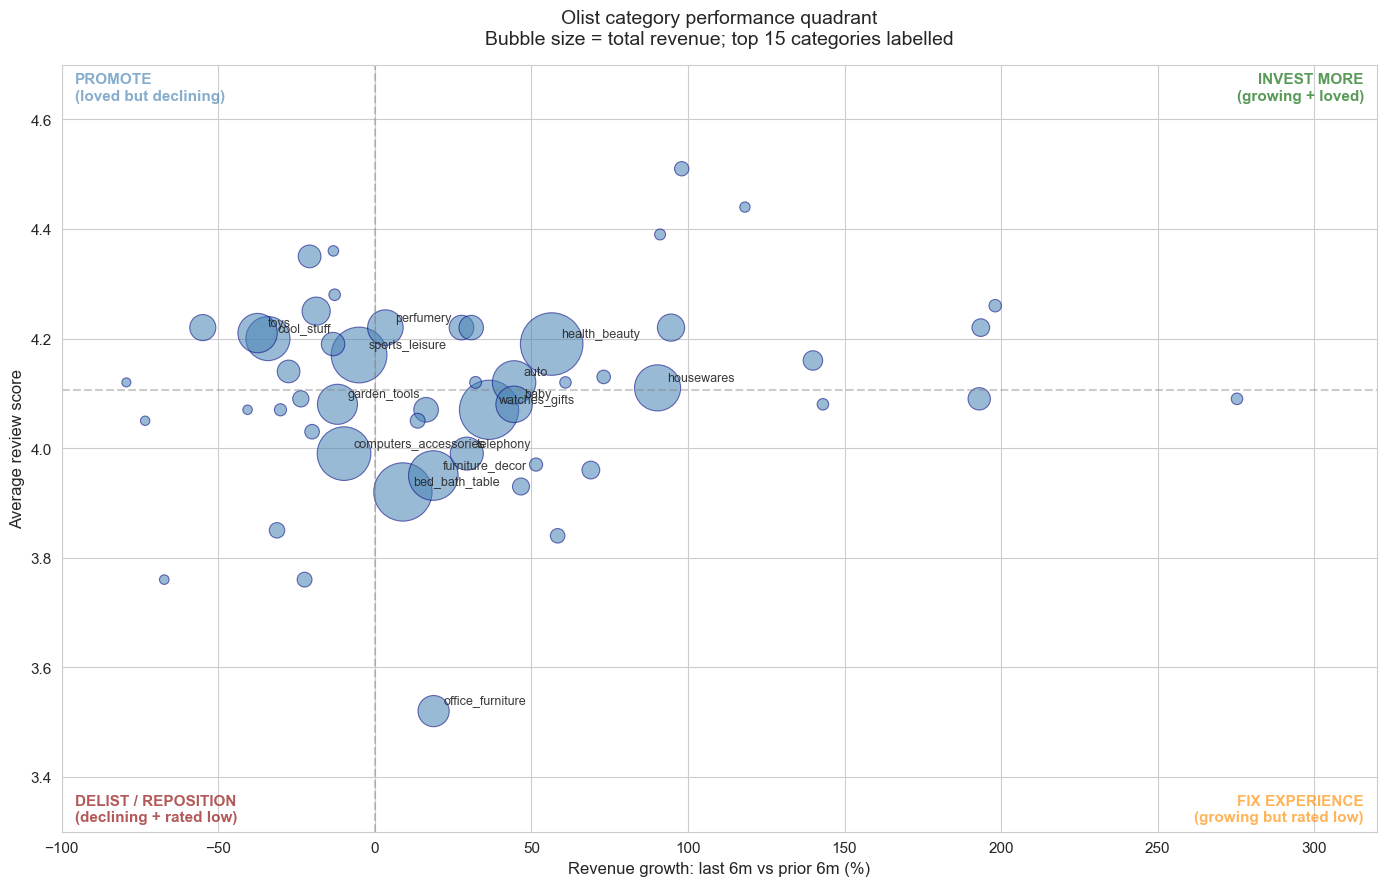


STRATEGIC ACTIONS BY QUADRANT

INVEST MORE (16 categories, 4.38M BRL):
   product_category  total_revenue  growth_pct  avg_review_score
      health_beauty     1412089.53        56.5              4.19
         housewares      758392.25        90.3              4.11
               auto      669454.75        44.5              4.12
          perfumery      443171.63         3.4              4.22
           pet_shop      250614.20        94.6              4.22
musical_instruments      202187.12        27.7              4.22
   small_appliances      198108.47        30.8              4.22
  home_appliances_2      118208.52       139.9              4.16

FIX EXPERIENCE (15 categories, 5.31M BRL):
               product_category  total_revenue  growth_pct  avg_review_score
                  watches_gifts     1264333.12        36.5              4.07
                 bed_bath_table     1225209.26         9.0              3.92
                furniture_decor      880329.92        18.7          

In [10]:
alpha_data = 0.55
alpha_background = 0.4
alpha_quadrant = 0.65
alpha_annotation = 0.9

fig, ax = plt.subplots(figsize=(14, 9))

size_scale = (quadrant_data['total_revenue']/quadrant_data['total_revenue'].max()) * 2000 + 30

scatter = ax.scatter(quadrant_data['growth_clipped'], quadrant_data['avg_review_score'], s=size_scale, alpha=alpha_data, c='steelblue', edgecolor='navy', linewidth=0.8)

ax.axvline(growth_midline, color='gray', linestyle='--', alpha=alpha_background)
ax.axhline(review_midline, color='gray', linestyle='--', alpha=alpha_background)

ax.text(0.99, 0.99, 'INVEST MORE\n(growing + loved)', transform=ax.transAxes, ha='right', 
        va='top', fontsize=11, color='darkgreen', alpha=alpha_quadrant, fontweight='bold')
ax.text(0.99, 0.01, 'FIX EXPERIENCE\n(growing but rated low)', transform=ax.transAxes, ha='right', 
        va='bottom', fontsize=11, color='darkorange', alpha=alpha_quadrant, fontweight='bold')
ax.text(0.01, 0.99, 'PROMOTE\n(loved but declining)', transform=ax.transAxes, ha='left', 
        va='top', fontsize=11, color='steelblue', alpha=alpha_quadrant, fontweight='bold')
ax.text(0.01, 0.01, 'DELIST / REPOSITION\n(declining + rated low)', transform=ax.transAxes, ha='left',
        va='bottom', fontsize=11, color='darkred', alpha=alpha_quadrant, fontweight='bold')

top_labels = quadrant_data.nlargest(15, 'total_revenue')
for _, row in top_labels.iterrows():
    label = row['product_category']
    if len(label) > 25:
        label = label[:22] + '...'
    ax.annotate(label, (row['growth_clipped'], row['avg_review_score']), xytext=(7, 5), textcoords='offset points', fontsize=9, alpha=alpha_annotation)

ax.set_xlabel('Revenue growth: last 6m vs prior 6m (%)', fontsize=12)
ax.set_ylabel('Average review score', fontsize=12)
ax.set_title('Olist category performance quadrant\n'
             'Bubble size = total revenue; top 15 categories labelled', fontsize=14, pad=15)
ax.set_ylim(3.3, 4.7)
ax.set_xlim(-100, 320)

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('STRATEGIC ACTIONS BY QUADRANT')
print('='*60)

invest = quadrant_data[(quadrant_data['growth_pct'] > 0) & (quadrant_data['avg_review_score'] >= review_midline)]
fix = quadrant_data[(quadrant_data['growth_pct'] > 0) & (quadrant_data['avg_review_score'] < review_midline)]
promote = quadrant_data[(quadrant_data['growth_pct'] <= 0) & (quadrant_data['avg_review_score'] >= review_midline)]
delist = quadrant_data[(quadrant_data['growth_pct'] <= 0) & (quadrant_data['avg_review_score'] < review_midline)]

print(f'\nINVEST MORE ({len(invest)} categories, {invest['total_revenue'].sum()/1e6:.2f}M BRL):')
print(invest.nlargest(8, 'total_revenue')[['product_category', 'total_revenue', 'growth_pct', 'avg_review_score']].to_string(index=False))

print(f'\nFIX EXPERIENCE ({len(fix)} categories, {fix['total_revenue'].sum()/1e6:.2f}M BRL):')
print(fix.nlargest(8, 'total_revenue')[['product_category', 'total_revenue', 'growth_pct', 'avg_review_score']].to_string(index=False))

print(f'\nPROMOTE / CROSS-SELL ({len(promote)} categories, {promote['total_revenue'].sum()/1e6:.2f}M BRL):')
print(promote.nlargest(8, 'total_revenue')[['product_category', 'total_revenue', 'growth_pct', 'avg_review_score']].to_string(index=False))

print(f'\nDELIST / REPOSITION ({len(delist)} categories, {delist['total_revenue'].sum()/1e6:.2f}M BRL:')
print(delist.nlargest(8, 'total_revenue')[['product_category', 'total_revenue', 'growth_pct', 'avg_review_score']].to_string(index=False))

## Summary

Category analysis reveals a clear strategic picture:

- **35% of marketplace revenue sits in "Fix Experience"**: categories that are growing but rated below the marketplace average. Four priority categories drive most of that exposure (bed_bath_table (1.22M), watches_gifts (1.26M), furniture_decor (880K), and office_furniture (335K)), with office_furniture as the standout problem with a 3.52 review score, the lowest of any meaningful-volume category.

- **Housewares is the standout "Invest More" opportunity**: 90% growth, 4.11 review score, 452 distinct sellers. This combination is rare across the catalogue.

- **The DELIST quadrant is small**: only 13% of revenue. Olist's category strategy is closer to "fix what works" than "cut the dead weight".

These findings drive Recommendation 1 in the commercial memo and the broader category prioritisation logic. 